### Метод K блиайших соседей

#### Цель работы

Изучить работу класса KNeighborsClassifier библиотеки Scikit-Learn, реализующего метод K ближайших соседей для классификации.

#### Содержание работы

1. Загрузить датасет "Ирисы" и выбрать в обучающую выборку только первый и третий столбцы в качестве признаков.
1. Проведите минимаксную нормализацию данных.
1. Посроить модель классификации по методу ближайших соседей с k=3 и оценить эффективность этой модели.
1. Создать новое наблюдение, шкалировать его и сделать предсказание на нём. Вывести расстояния до трёх ближайших соседей. Вывести индексы и координаты трёх ближайших соседей. Визуализировать их.

#### Методические указания

Для рассмотрения метода ближайших соседей возьмем набор данных "Ирисы", встроенный в библиотеку sklearn. Загрузим данные:

In [113]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [114]:
iris = load_iris() 
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


В этом наборе данных четыре атрибута - характеристики различных растений. Для более точной классификации может понадобиться использовать все имеющиеся данные. Но для визуализации процесса классификации выберем только два столбца. В данном примере возьмем первый и третий столбцы - длину чашелистика и длины лепестка соответственно:

In [115]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

Визуалиируем данные по классам:

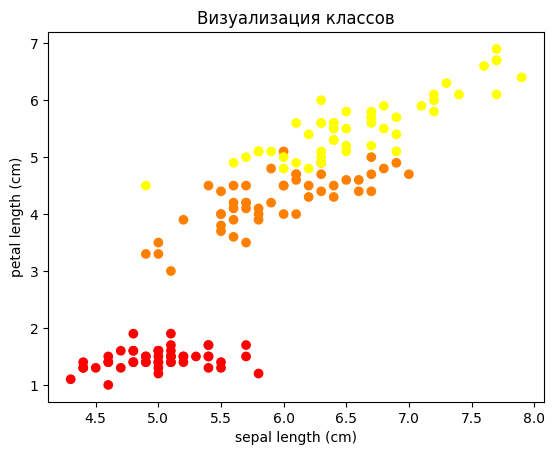

In [116]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

Мы имеем задачу множественной классификации с тремя классами - различными видами ирисов. 

Для применения метода ближайших соседей данные обязательно нужно нормализовать. Ранее в других работах мы пользовались объектом StandartScaler, который приводит распределение каждого признака к стандартному виду. Сейчас же для иллюстрации разных видов нормализации воспользуемся другим объектом - MinMaxScaler, который производит минимаксную нормализацию. Работа с этим объектом полностью аналогична:


In [117]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

При визуализации нормализованного датасета видим следующую картину:

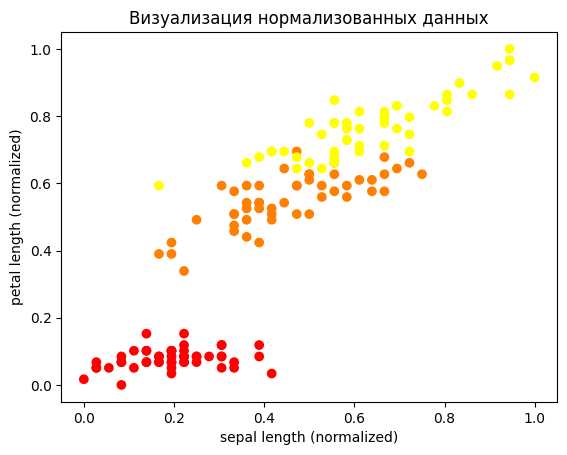

In [118]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')
plt.title("Визуализация нормализованных данных")
plt.xlabel('sepal length (normalized)')
plt.ylabel('petal length (normalized)')
plt.show()

Взаимное расположение точек не изменилось, но все значения по обеим осям масштабированы таким образом, чтобы занимать интервал от 0 до 1. Такие данные уже можно использовать для построения метода ближайших соседей.

Для построения модели создадим объект, обучим его на нашем наборе данных (обратите внимание, что мы используем нормализованный вариант данных) и сделаем предсказание:

In [119]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)

Для оценки качества работы полученной модели выведем матрицу классификации:

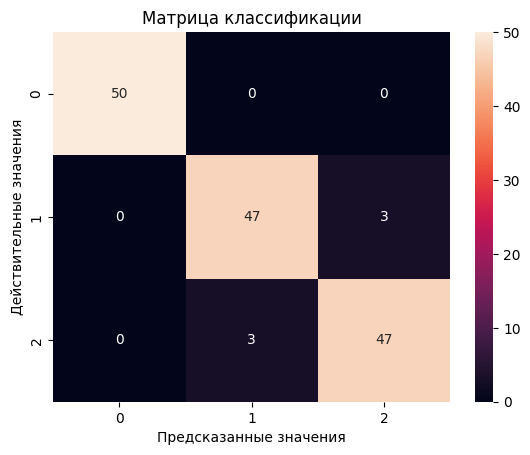

In [120]:
plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt ='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

Мы видим, что в целом модель работает очень адекватно, из 150 точек неправильно распознает всего шесть. При этом, модель путает только второй и третий классы между собой. Первый класс модель всегда определяет безошибочно. Дополнительно мы можем вывести метрики качества множественной классификации в отчете о классификации:

In [121]:
print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



Здесь мы видим, что в целом наша модель имеет 96% точности, что свидетельствует о ее высоком качестве.

Теперь попробуем визуализировать области классификации, то есть построить границы принятия решений. Для этого, как и в предыдущих работах, будем использовать контурный график. Подготовим данные:

In [122]:
X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

Обратите внимание, что мы для подготовки равномерной сетки используем исходный датасет, а ненормированный. Дело в том, что мы хотим построить график в пространстве исходных признаков, а не в искаженном масштабе нормализованных данных. Но для выполнения предсказания эти сгенерированные данные тоже нужно будет нормализовать:

In [123]:
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


При этом важно, чтобы вы использовали именно тот же объект нормализации, который обучили на исходном датасете. Дело в том, что для данной модели теперь нужно будет использовать именно те параметры нормализации, которые были подобраны (или вычислены) по исходной выборке. После нормализации и получения предсказания можно строить графики:

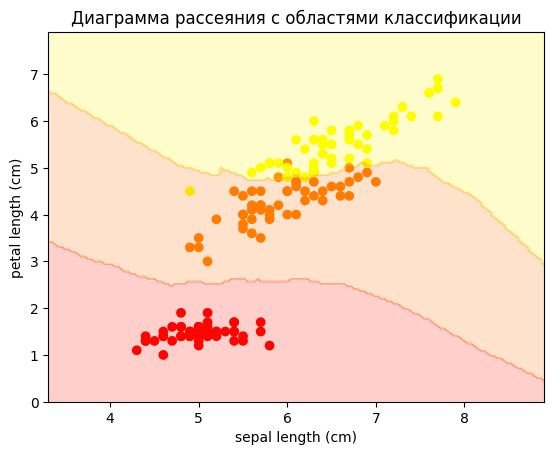

In [124]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()


Теперь создадим новое наблюдение (новый объект), которое мы хотим классифицировать:

In [125]:
observation_new = [[5.5, 5]]

Перед передачей его в модель машинного обучения его также обязательно нужно нормализовать:

In [126]:
observation_new_scaled = scaler.transform(observation_new)

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Очень просто можно посмотреть, к какому классу модель относит данный объект:

In [127]:
knn.predict(observation_new_scaled)

array([2])

Также соответствующий метод объекта модели позволит увидеть вероятности отнесения данного объекта к каждому классу модели:

In [128]:
knn.predict_proba(observation_new_scaled)

array([[0., 0., 1.]])

Эти методы устроены точно также, как и в других моделях библиотеки sklearn. А вот специфическое поведение модели ближайших соседей - данный объект позволяет увидеть, какие объекты обучающей выборки модель нашла как ближайшие к новому:

In [129]:
distances, indices = knn.kneighbors(observation_new_scaled)

Используя эти данные, очень просто можно визуализировать ближайших соседей к заданной точке на графике:

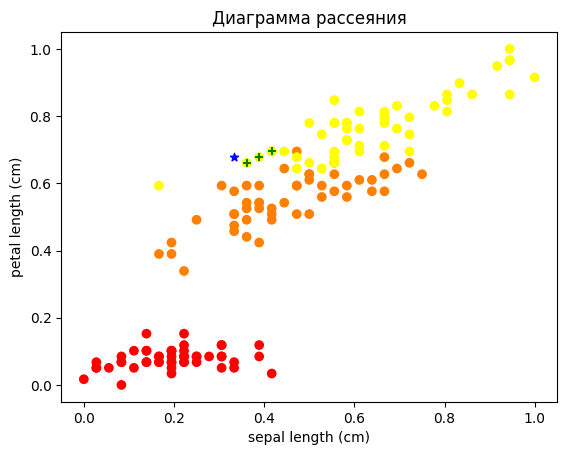

In [130]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

### Контрольные вопросы

**1. Чем отличается стандартизация и минимаксная нормализация данных? Есть ли другие методы нормализации данных? Когда следует применять какие методы?**

Стандартизация (StandardScaler) приводит данные к нулевому среднему и единичному стандартному отклонению: z = (x - μ) / σ. Минимаксная нормализация (MinMaxScaler) масштабирует данные в заданный диапазон, обычно [0, 1]: x' = (x - min) / (max - min). Другие методы: RobustScaler (устойчив к выбросам, использует медиану и IQR), MaxAbsScaler (масштабирует на максимальное абсолютное значение), нормализация по длине вектора (L1, L2). MinMaxScaler применяют, когда данные имеют ограниченные границы и нет сильных выбросов. StandardScaler — когда данные близки к нормальному распределению или при использовании методов, чувствительных к масштабу (PCA, SVM, линейные модели). RobustScaler — при наличии выбросов.

**2. В чем смысл параметра k в алгоритме ближайших соседей? Как его выбирать?**

Параметр k определяет количество ближайших соседей, учитываемых при голосовании (в классификации) или усреднении (в регрессии). Малые k делают модель чувствительной к шуму (переобучение), большие k сглаживают границу, но могут потерять локальные закономерности (недообучение). k выбирают экспериментально с помощью кросс-валидации, часто подбирая нечётное значение (3, 5, 7, 9) чтобы избежать равенства голосов в классификации.

**3. Чем отличается взвешенный и равномерный вариант метода ближайших соседей? Когда применять какой?**

При равномерном (uniform) все k соседей имеют равный вес при голосовании или усреднении. При взвешенном (distance) вес каждого соседа обратно пропорционален расстоянию до него (ближние соседи имеют больший вес). Равномерный вариант применяют, когда данные равномерно распределены и все соседи примерно одинаково важны. Взвешенный вариант предпочтительнее при неоднородной плотности данных, так как он уменьшает влияние далёких соседей и делает границы более гладкими.

**4. Почему нормализованное по минимаксному методу значение может быть больше 1?**

Нормализованное по MinMaxScaler значение не может быть больше 1 в теории, так как формула (x - min) / (max - min) использует min и max из обучающей выборки. Однако если при трансформации нового наблюдения его значение выходит за пределы интервала [min, max] обучающей выборки, результат окажется меньше 0 или больше 1. Это сигнализирует, что новое наблюдение лежит вне диапазона исходных данных.

**5. Что такое метрики расстояния и как они влияют на работу метода ближайших соседей?**

Метрики расстояния — функции, измеряющие близость между объектами. Основные метрики: евклидово (L2), манхэттенское (L1), чебышёва (L∞), косинусное расстояние. Выбор метрики определяет форму "окрестности" — евклидово даёт сферические окрестности, манхэттенское — ромбовидные. Это влияет на то, какие точки считаются ближайшими, и может существенно изменить результат классификации или регрессии, особенно в пространствах с признаками разного масштаба (поэтому нормализация критична).